In [1]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

sns.set() # default style of seaaborn

import warnings as wns
wns.filterwarnings("ignore")

In [57]:
df = pd.read_csv(r"C:\Users\HP\Documents\heart.csv")  #Importing the dataset

In [59]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
dg = df.copy()

In [4]:
df.shape    #This shows the number of rows and columns of the dataset

(1025, 14)

In [5]:
df.info()  #This shows the datatypes of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isna().sum()  #This shows that there are no null values in the dataset.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()   #This shows the number of duplicated values in the dataset

np.int64(723)

In [70]:
dc = df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_log,oldpeak_log,thalach_clean
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,5.361292,0.693147,168.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,5.318120,1.410987,155.0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,5.164786,1.280934,125.0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,5.318120,0.000000,161.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,5.686975,1.064711,106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1,5.356586,0.916291,115.0
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1,4.955827,0.470004,175.0
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0,5.545177,0.000000,161.0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0,5.613128,0.000000,125.0


### To Check for Count of Outliers in each columns

In [8]:
def detect_outliers_IQR(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - (IQR * 1.5)
    upper_limit = Q3 + (IQR * 1.5)
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers")
    return outliers

for col in ['trestbps','chol','thalach','oldpeak','thal','ca','thal']:
    detect_outliers_IQR(df, col)

trestbps: 30 outliers
chol: 16 outliers
thalach: 4 outliers
oldpeak: 7 outliers
thal: 7 outliers
ca: 87 outliers
thal: 7 outliers


#### Visualizing the outliers using Boxplots

The boxplot for trestbps


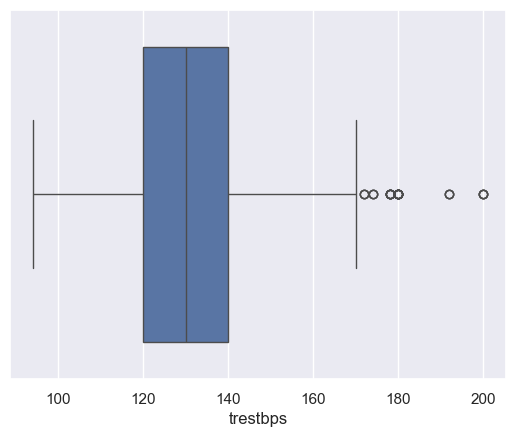

The boxplot for chol


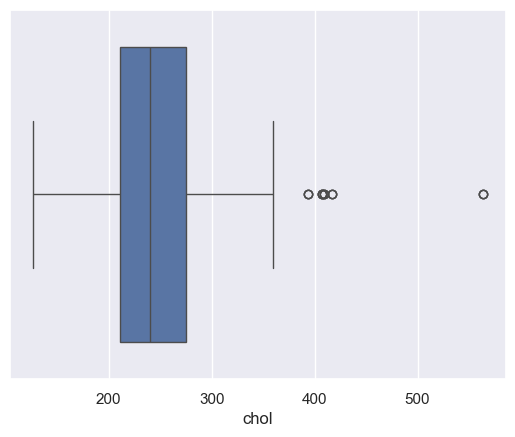

The boxplot for thalach


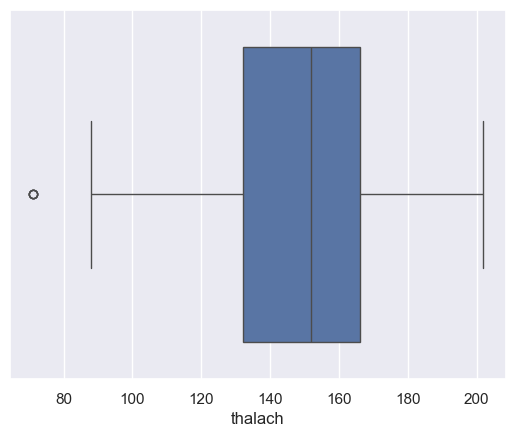

The boxplot for oldpeak


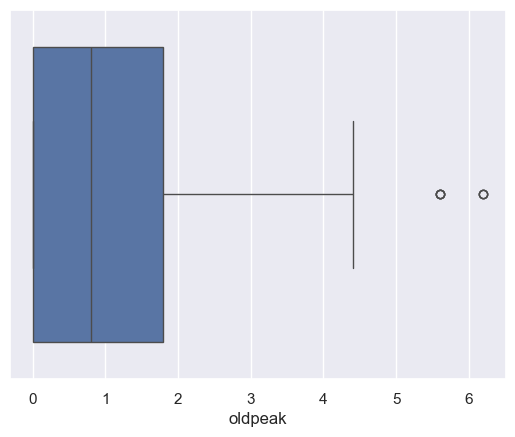

The boxplot for ca


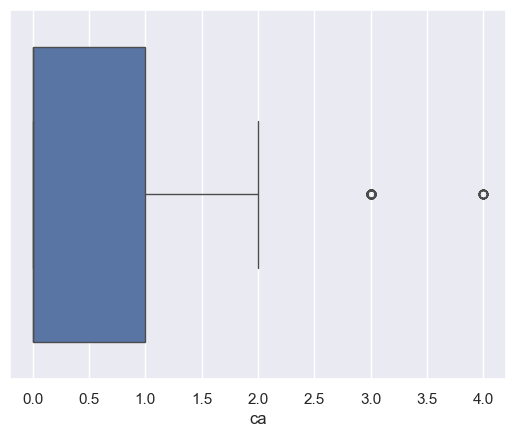

The boxplot for thal


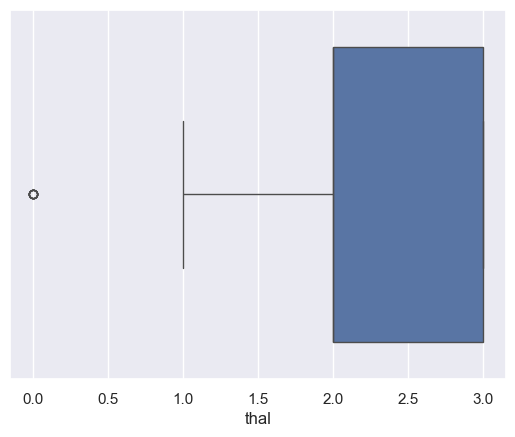

In [9]:
for col in ['trestbps','chol','thalach','oldpeak','ca','thal']:
    sns.boxplot(data = df, x = col)
    print(f"The boxplot for {col}")
    plt.show()

#### Examining the Real Values of Outliers from each column

In [10]:
col = ['trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

for c in col:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    # Filter outliers for this column only
    outliers = df[(df[c] < lower_limit) | (df[c] > upper_limit)]

    # Drop NaN values and show a few samples
    print(f"\nOutliers in '{c}':")
    display(outliers[[c]].dropna().tail(10))


Outliers in 'trestbps':


,trestbps
624,178
636,174
679,180
688,200
837,172
891,180
896,178
944,178
971,172
986,180



Outliers in 'chol':


,chol
464,564
481,407
542,394
578,394
641,409
665,417
685,407
889,407
958,417
996,409



Outliers in 'thalach':


...

,oldpeak
54,5.6
55,5.6
69,6.2
393,6.2
526,6.2
613,5.6
833,5.6



Outliers in 'ca':


,ca
950,3
955,3
962,3
970,4
979,3
985,3
993,4
1003,3
1013,3
1015,3



Outliers in 'thal':


,thal
14,0
319,0
329,0
359,0
686,0
734,0
893,0


#### Handling each column appropriately
**log-transform** fits because
columns like **chol** ,**oldpeak** and **thalach** are continuous and are Skewed with some large values (like 4–6) for **oldpeaks** and > 400 for **chols**.
Goal: To normalize distribution.


Because **thal** and **ca** are categorical, not continuous — so we don’t “normalize” or “log-transform” it.
Instead, we treat the outlier (0) by replacing or capping it with a valid category

In [60]:
df['chol_log'] = np.log1p(df['chol'])

df['oldpeak_log'] = np.log1p(df['oldpeak'])

df['ca'] = df['ca'].astype('category')

df['ca'] = df['ca'].replace(4, df['ca'].mode()[0])

df['thal'] = df['thal'].replace(0, df['thal'].mode()[0])

df['thal'] = df['thal'].astype('category')

#Capping (Winsorizing) the Outliers of 'thalach' because its original distribution is closer to normal distribution and its left skewed

Q1 = df['thalach'].quantile(0.25)
Q3 = df['thalach'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

df['thalach_clean'] = np.where(df['thalach'] < lower_limit, lower_limit,
                np.where(df['thalach'] > upper_limit, upper_limit, df['thalach']))


In [11]:
df.info()  #This is to confirm the new datatype of ca and thal

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


#### Comparing Normal 'chol', 'oldpeak' with  and after Log transformation

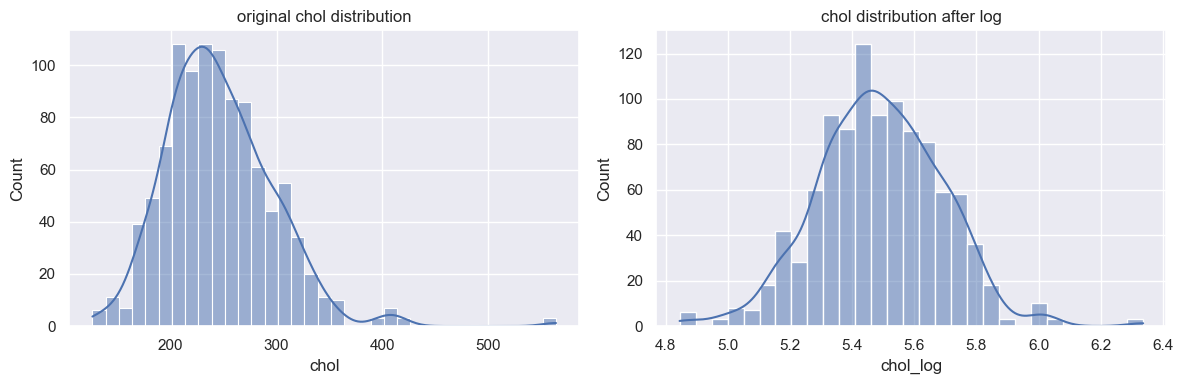

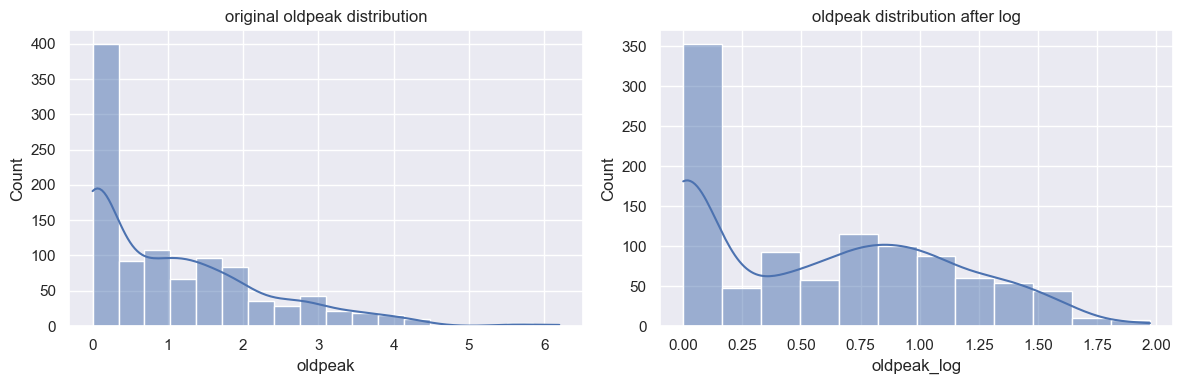

In [64]:
col_to_plot = ['chol', 'oldpeak']

for col in col_to_plot:
    fig, ax = plt.subplots(1,2 ,figsize = (12,4))
    sns.histplot(x= df[col], kde= True, ax=ax[0])
    ax[0].set_title(f"original {col} distribution")

    sns.histplot(df[f'{col}_log'], kde=True, ax=ax[1])
    ax[1].set_title(f'Log {col}')
    ax[1].set_title(f"{col} distribution after log")

    

    

    

    plt.tight_layout()
    plt.show()

#### Comparing Normal 'thalach', 'thalach_clean' distribution

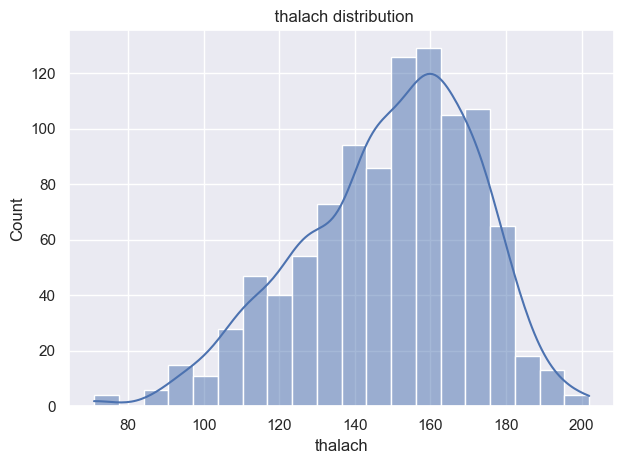

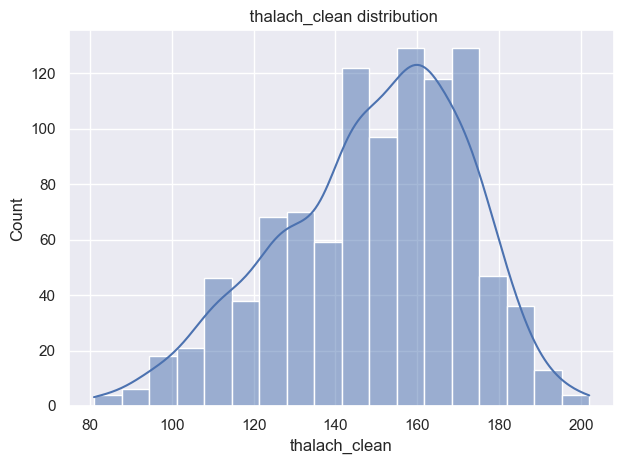

In [66]:
col_to_plots = ['thalach', 'thalach_clean']

for col in col_to_plots:
    sns.histplot(x= df[col], kde= True)
    plt.title(f" {col} distribution")

   

    plt.tight_layout()
    plt.show()

#### Count of ca and thal with target

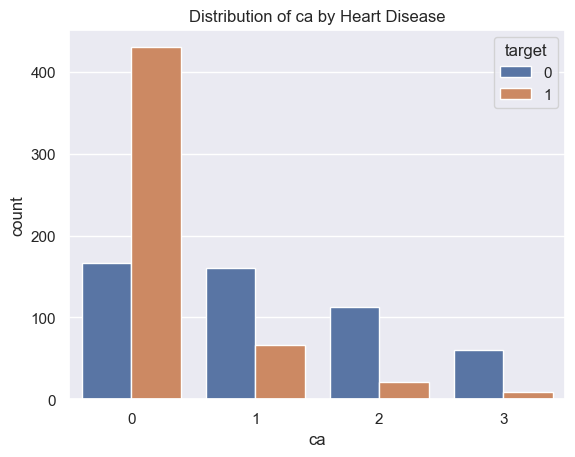

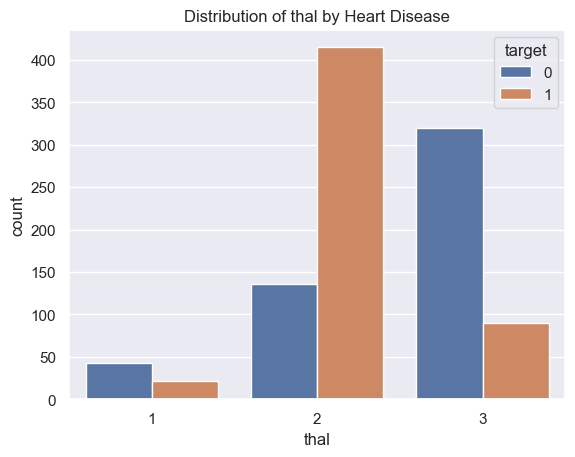

In [27]:
for col in ['ca', 'thal']:
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f'Distribution of {col} by Heart Disease')
    plt.show()

##### Exceptions to outliers

- The outliers of **trestbps**(Resting Blood Pressure) is not removed because they are true extreme cases **(172 - 200)** — not necessarily errors — since the dataset includes patients with heart disease which may indicates extreme hypertension.


#### Describtion of each features

In [73]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target,chol_log,oldpeak_log,thalach_clean
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.513171,5.488676,0.584147,149.153171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,0.500070,0.202787,0.527888,22.881210
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,4.844187,0.000000,81.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,5.356586,0.000000,132.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,1.000000,5.484797,0.587787,152.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,5.620401,1.029619,166.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000,6.336826,1.974081,202.000000


#### Correlation between the features with the target

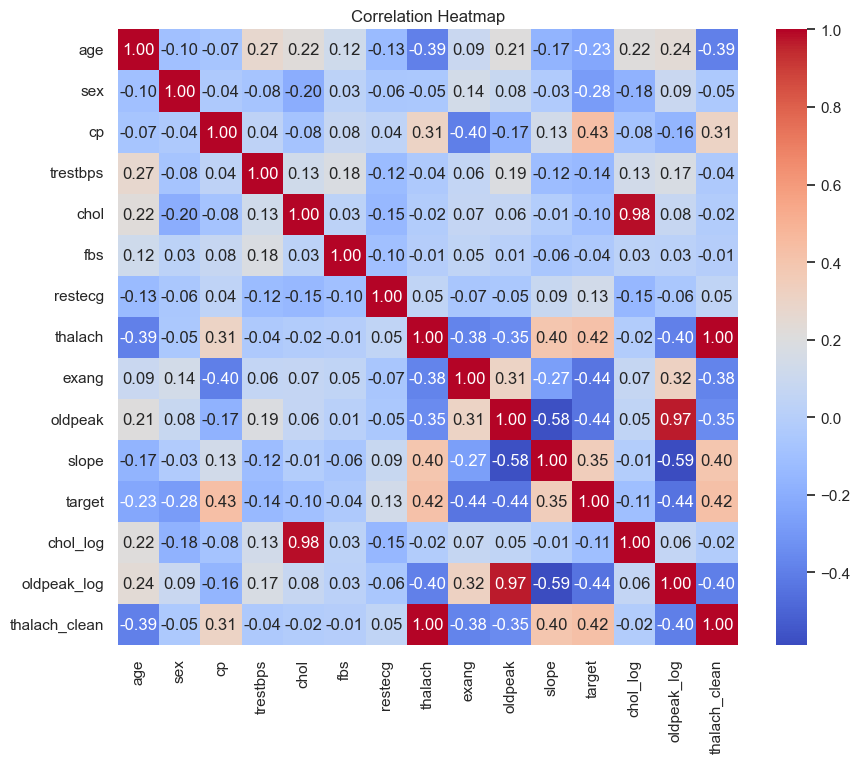

In [72]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### chest pain vs heart diseases

In [77]:
df["cp"].value_counts()

cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

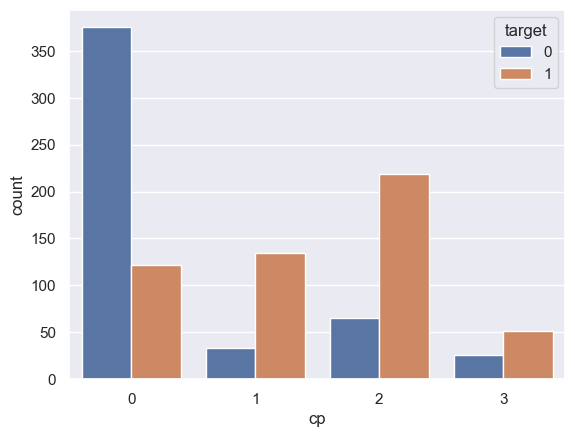

In [76]:
sns.countplot(data = df, x = "cp", hue="target" )

plt.show()


##### chest pain type condition **1 and 2** has more positive heart disease patient despite being lower in population than the chest pain type condition **1**, while chest pain type condition **3** has the lowest positive heart disease patients

#### What percentage of patients that have heart disease vs no heart disease?

In [78]:
df["target"].value_counts(normalize= True) * 100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

In [80]:
patient_counts = df["target"].value_counts()  #this show the counts of patients that have heart disease vs no heart disease
patient_counts

target
1    526
0    499
Name: count, dtype: int64

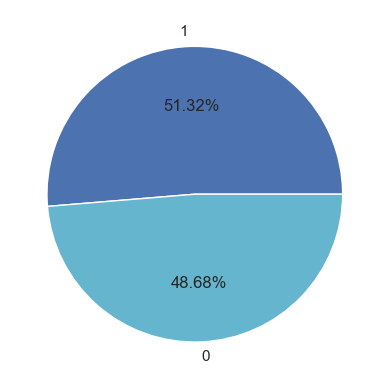

In [83]:
plt.pie(patient_counts, autopct="%1.2f%%", labels= patient_counts.index, colors= ["b", "c"])

plt.show()

#### What is the age distribution of patients in the dataset?

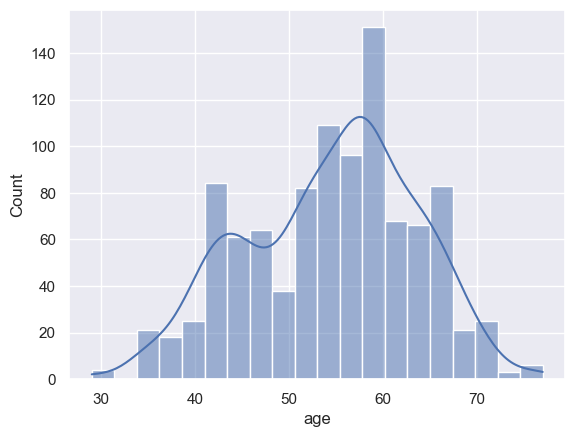

In [84]:
sns.histplot( data = df, x = "age",bins = 20, kde = True)

plt.show()

#### Comparing gender population with target

In [85]:
gender_count = df["sex"].value_counts()

gender_count

sex
1    713
0    312
Name: count, dtype: int64

In [86]:
gender_positive_count = df.groupby("sex")["target"].sum()

gender_positive_count

sex
0    226
1    300
Name: target, dtype: int64

In [87]:
sex_count_tar = pd.merge(gender_count,gender_positive_count, on= "sex", how="inner").reset_index()

sex_count_tar

,sex,count,target
0,1,713,300
1,0,312,226


In [89]:
sex_count_tar["percentage"] = (sex_count_tar["target"] / sex_count_tar["count"]) * 100

sex_count_tar

,sex,count,target,percentage
0,1,713,300,42.075736
1,0,312,226,72.435897


<Axes: xlabel='sex', ylabel='count'>

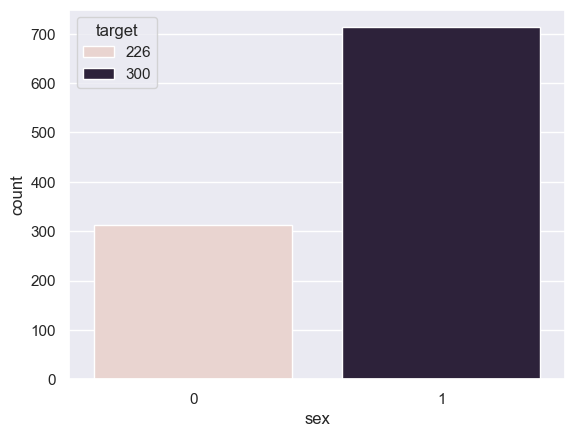

In [98]:
sns.barplot(data = sex_count_tar, y = "count", x = "sex", hue="target")

##### The table shows women are most likely having the disease than men comparing the original population with the postive population.

#### Which age group shows higher heart disease rates?

In [99]:
age_heart = df.groupby("age")["target"].sum()  #This shows how many patients has heart disease by there age
age_heart.head()

age
29    4
34    6
35    8
37    6
38    8
Name: target, dtype: int64

In [100]:
def age_group(row):                      #defining age_group function to group the patients age into categories
    if 29 <= row <= 39:
        return "Young Adult(29-30)"
    if 40 <= row <= 49:
        return "Early Middle Age(40-49)"
    if 50 <= row <= 59:
        return "Middle Age(50-59)"
    if 60 <= row <= 69:
        return "Older Adult(60-69)"
    if row >= 70:
        return "Elderly(70+)"

In [101]:
df["age group"] = df["age"].apply(age_group)   #applying the function to age column to create a new column called age group

In [102]:
age_group__targ = df.groupby("age group")["target"].sum()

age_group__targ

age group
Early Middle Age(40-49)    157
Elderly(70+)                20
Middle Age(50-59)          206
Older Adult(60-69)         101
Young Adult(29-30)          42
Name: target, dtype: int64

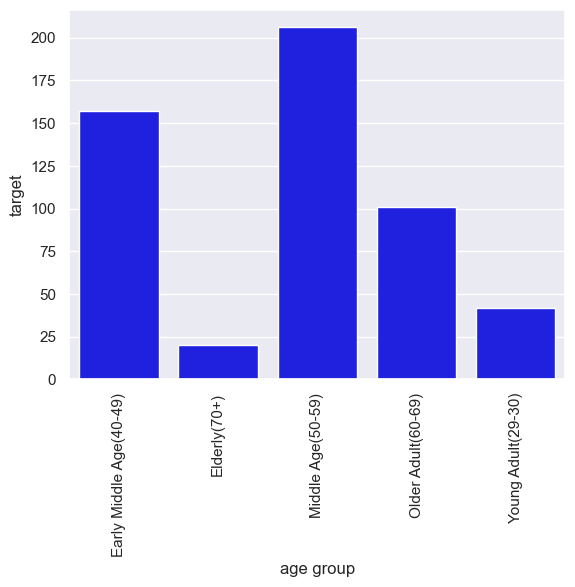

In [103]:
sns.barplot(age_group__targ, color = "blue")
plt.xticks(rotation = 90)

plt.show()

#### How does chest pain type vary between male and female?

In [104]:
gender_cp = df.groupby(["cp", "sex"]).size().reset_index(name = "count")

gender_cp

,cp,sex,count
0,0,0,133
1,0,1,364
2,1,0,57
3,1,1,110
4,2,0,109
5,2,1,175
6,3,0,13
7,3,1,64


In [105]:
gender_cp["sex"]=gender_cp["sex"].replace({0:"female", 1:"male"})  # use the real gender name for clearer understanding
gender_cp

,cp,sex,count
0,0,female,133
1,0,male,364
2,1,female,57
3,1,male,110
4,2,female,109
5,2,male,175
6,3,female,13
7,3,male,64


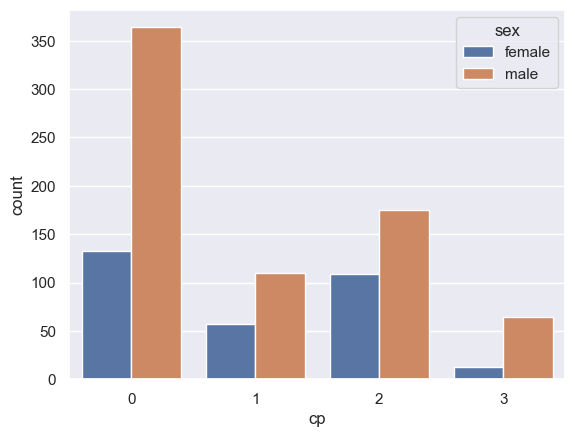

In [106]:
sns.barplot(data = gender_cp, x = "cp", y = "count", hue= "sex" )

plt.show()

##### Across all the chest pain, male patient are dominant than the female patient

#### How do average cholesterol (chol) and blood pressure (trestbps) differ between patients with and without heart disease?

In [108]:
df.groupby("target")[["trestbps","chol"]].agg([np.mean]).reset_index()

,target,trestbps,chol
,,mean,mean
0,0,134.106212,251.292585
1,1,129.245247,240.979087


In [111]:
import scipy         # T-test to show if the difference in mean is statistically significant
from scipy.stats import ttest_ind

In [113]:
grp_disease = df[df["target"] == 1]   #filtering the data to patient that are positive and negative
grp_no_disease = df[df["target"] == 0]

In [114]:
#T-test to show if the difference in mean is statistically significant

t_stat_bp, p_val_bp  = ttest_ind(grp_disease["trestbps"], grp_no_disease["trestbps"], equal_var= False)
print("t_statistics:", round(t_stat_bp,3) ,",  p-value:", round(p_val_bp,7))

t_statistics: -4.465 ,  p-value: 8.9e-06


In [115]:
t_stat_chol, p_val_chol  = ttest_ind(grp_disease["chol"], grp_no_disease["chol"], equal_var= False)

print("t_statistics:", round(t_stat_chol,3) ,",  p-value:", round(p_val_chol ,7))

t_statistics: -3.219 ,  p-value: 0.0013262


##### The P-values shows Difference in mean is statistically significant for both trestbps and chol, and they aint just gotten